# V. SCALAR FIELD DYNAMICS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, trapezoid

In [ ]:
# Parameters
m = 0.1                     # Planck mass
t0, tf = 0.0, 50.0          # Temporal interval
n_points = 2000             # Resolution for t_eval


# Initial conditions
phi0 = 15.0                  # Planck mass
phidot0 = 0.1               # Planck mass
a0 = 1.0                    # Scale factor initial value

dt = 0.01
t_eval = np.arange(t0, tf, dt)

The Friedmann equation is used to "simplify" the Klein-Gordon equation.

Friedmann equation:
$$
H^2 = \frac{1}{3}\rho_\phi = \frac{1}{3}\left(\frac{1}{2}\dot{\phi}^2 + V(\phi)\right) = \frac{1}{6}\left(\dot{\phi}^2 + m^2\phi^2\right)
$$

Rewritten as:
$H = \sqrt{\frac{1}{6}\left(\dot{\phi}^2 + m^2\phi^2\right)}$

Inserted into the equation of motion:
$$
\ddot{\phi} = -3 \left[ \sqrt{\frac{1}{6} \left( \dot{\phi}^2 + m^2\phi^2 \right)} \right] \dot{\phi} - m^2\phi
$$

In [ ]:
# Inflation equation
def equation(phi, t):
    return [phi[1], -3 * np.sqrt( (phi[1]**2 + (m * phi[0])**2) / 6 ) * phi[1] - phi[0] * m**2]

phi, phi_dot = odeint(equation, [phi0, phidot0], t_eval).T

# Potential and Hubble parameter
V = (m *  phi)**2 / 2
H = np.sqrt( (phi_dot**2 + (m * phi)**2) / 6 )

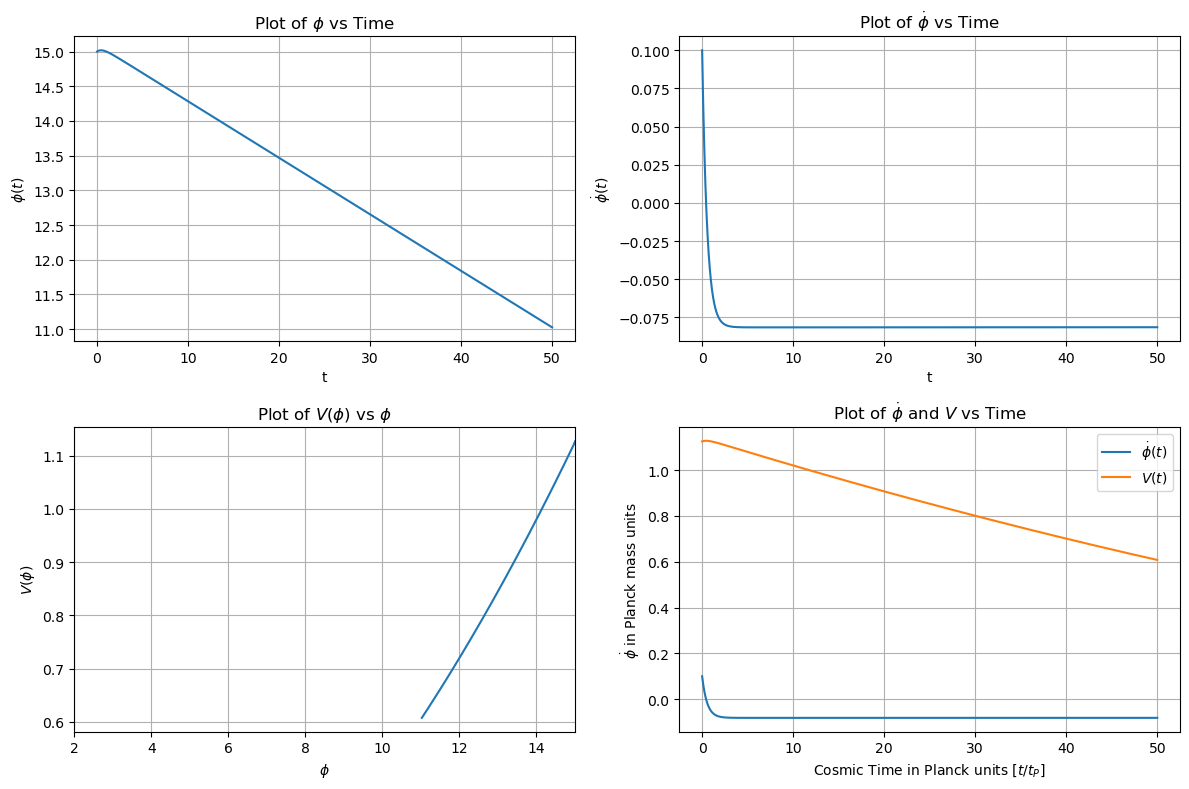

phi(tf) = 11.024974692840882
phi_dot(tf) = -0.0814302039088412
V(tf) = 0.6077503348889096


In [ ]:
# Plotting the results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t_eval, phi)
plt.xlabel('t')
plt.ylabel(r'$\phi(t)$')
plt.grid(True)
plt.title(r'Plot of $\phi$ vs Time')

plt.subplot(2, 2, 2)
plt.plot(t_eval, phi_dot)
plt.xlabel('t')
plt.ylabel(r"$\dot{\phi}(t)$")  
plt.grid(True)
plt.title(r'Plot of $\dot{\phi}$ vs Time')

plt.subplot(2, 2, 3)
plt.plot(phi, V)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$V(\phi)$')  
plt.xlim(2, 15)
plt.grid(True)
plt.title(r'Plot of $V(\phi)$ vs $\phi$')

plt.subplot(2, 2, 4)
plt.plot(t_eval, phi_dot, label=r'$\dot{\phi}(t)$')
plt.plot(t_eval, V, label=r'$V(t)$')
plt.xlabel(r'Cosmic Time in Planck units $[t/t_P]$')
plt.ylabel(r'$\dot{\phi}$ in Planck mass units')
plt.legend(loc='best')
plt.grid(True)
plt.title(r'Plot of $\dot{\phi}$ and $V$ vs Time')

plt.tight_layout()

plt.show()

# Prints some useful values at the final time
print("phi(tf) =", phi[-1])
print("phi_dot(tf) =", phi_dot[-1])
print("V(tf) =", V[-1])

1. $\Phi(t)$ vs $t$

    We observe the inflaton field $\Phi$ slowly rolling down its potential. The key feature is that the slope is nearly constant, meaning the velocity $\dot{\Phi}$ is essentially steady. The field has reached a "terminal velocity," entering what is known as the slow-roll attractor regime. The enormous Hubble friction ($3H\dot{\Phi}$), caused by the rapid expansion of the universe, damps the field's motion so effectively that it perfectly balances the gradient of the potential ($-V'(\Phi)$) pushing it downward.

2. $\dot{\Phi}(t)$ vs $t$

    This plot shows that regardless of the initial conditions, the Hubble friction is so dominant that it damps the initial transient dynamics almost instantaneously. The velocity plummets and locks into a steady, small negative value, firmly settling onto the slow-roll attractor solution.

3. $V(\Phi)$ vs $\Phi$

    The plot of the inflaton potential.

4. $\dot{\Phi}(t)$ and $V(t)$ vs Time
    
    The fundamental requirement for slow-roll inflation is that the potential energy must completely dominate over the kinetic energy. The plot visually confirms this first slow-roll condition: $V(\Phi) \gg \frac{1}{2}\dot{\Phi}^2$. Because the potential energy dominates, the equation of state parameter for the universe ($w = P/\rho$) approaches $w \approx -1$. This strongly negative pressure is precisely what drives the exponential, accelerated expansion of the universe known as Inflation.

In [ ]:
# Plotting the Hubble parameter
plt.plot(t_eval, H, label=r'Hubble parameter')
plt.xlabel(r'Cosmic Time in Planck$\'s$ unit $[t/t_P]$')
plt.ylabel('H')
plt.legend()
plt.show()

plt.tight_layout()

plt.show()

$H$ is decreasing slowly and by a very small amount, which is clear evidence of the slow-roll regime (a quasi-de Sitter expansion).

The slow-roll parameter can be defined kinematically (the Hubble flow parameter) as:
$$\epsilon = -\frac{\dot{H}}{H^2}$$

and in terms of the potential (the potential slow-roll parameter) as:
$$\epsilon_V \approx \frac{1}{2} M_{Pl}^2 \left(\frac{V'}{V}\right)^2$$

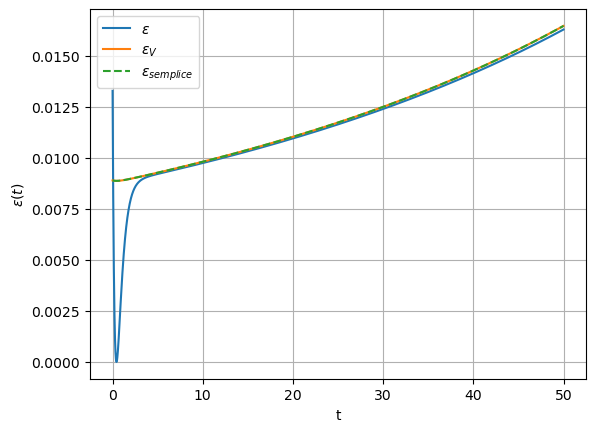

In [ ]:
# SLOW ROLL

epsilon = 0.5* phi_dot**2 / H**2
V_dot = - phi * m**2
eps_v = 0.5*((m**2*phi) / (0.5*(m*phi)**2))**2
eps_semplice = 2*(1 / phi)**2
plt.plot(t_eval, epsilon,label=r'$\epsilon$')
plt.plot(t_eval, eps_v,label=r'$\epsilon_{V}$')
plt.plot(t_eval, eps_semplice,label=r'$\epsilon_{semplice}$',ls = '--')
plt.xlabel('t')
plt.ylabel(r'$\epsilon(t)$')

plt.legend()
plt.grid(True)
plt.show()

The blue curve exhibits an initial spike due to an excessively high initial kinetic energy. However, after a short time, Hubble friction damps this transient motion, and the curve converges with the others onto the slow-roll attractor. They all then rise slowly until reaching the condition where the slow-roll approximation breaks down (which would require a longer simulation time to fully observe).

The following slow-roll variables are also calculated and plotted:
$\delta = -\frac{\ddot{\phi}}{H\dot{\phi}}$;
$\eta = 2(\epsilon - \delta)$; and
$\eta_V = \frac{m^2}{0.5(m\phi)^2}$

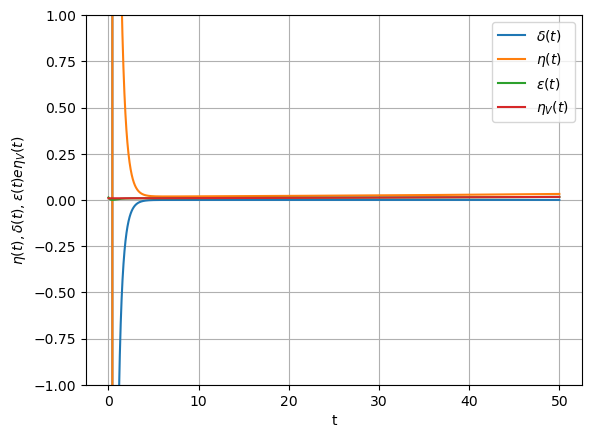

H  = 0.6131540317140726
phi(tf) = 15.01738843891806
phi_dot(tf) = 0.022970511309786005
phi_ddot(tf)=  -0.1924272692495676
delta(tf) = 13.662380177496999
eta(tf) = -27.323356888178434


In [ ]:
# phi_ddot
phi_ddot = -3 * H * phi_dot - phi * m**2

# delta
delta = - phi_ddot / (H*phi_dot)

# eta
eta = 2*(epsilon - delta)
eta_v = (m**2) / (0.5*(m*phi)**2)

plt.plot(t_eval, delta, label=r'$\delta(t)$')
plt.plot(t_eval, eta, label=r'$\eta(t)$')
plt.plot(t_eval,epsilon,label=r'$\epsilon(t)$')
plt.plot(t_eval,eta_v,label=r'$\eta_{V}(t)$')
plt.xlabel('t')
plt.ylabel(r'$\eta(t),\delta(t),\epsilon(t) e \eta_V(t) $')
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.show()
print("H  =", H[30])
print("phi(tf) =", phi[30])
print("phi_dot(tf) =", phi_dot[30])
print("phi_ddot(tf)= ", phi_ddot[30])
print("delta(tf) =", delta[30])
print("eta(tf) =", eta[30])


We see that although the initial kinetic energy is substantial—meaning the system does not start in a slow-roll state—Hubble friction quickly takes effect, rapidly driving the system into the slow-roll regime.

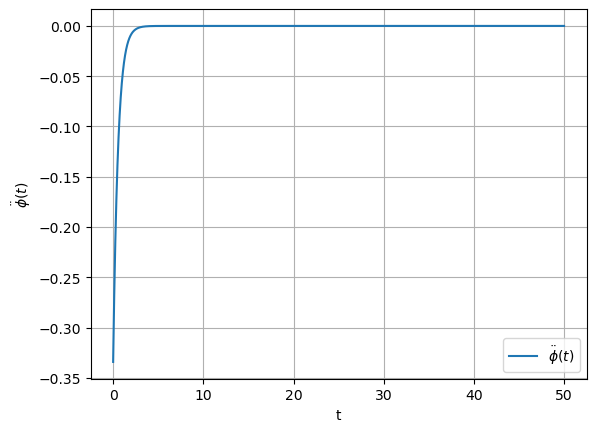

In [ ]:
plt.plot(t_eval,phi_ddot, label=r'$\ddot{\phi}(t)$')
plt.xlabel('t')
plt.ylabel(r'$\ddot{\phi}(t)$')
plt.legend()
plt.grid(True)
plt.show()

The first regime ($t < 4$) is a transient phase caused by excessively high initial kinetic energy. In the second regime, it can be seen that $\ddot{\Phi} \approx 0$, confirming that the velocity is constant. This satisfies the slow-roll condition, where the kinetic energy is negligible compared to the potential energy ($\frac{1}{2}\dot{\Phi}^2 \ll V(\Phi)$).

The number of e-folds is the standard measure of how much the universe expanded during inflation. It is defined as the natural logarithm of the ratio between the final and initial scale factors: $N = \ln(a_{\text{final}} / a_{\text{initial}})$.

In [ ]:
N = trapezoid(H, t_eval)
print(f"Number of e-folds N = {N:.2f}")

Number of e-folds N = 26.71


In [ ]:
# Second set of initial conditions

phi0_2 = 10.
phi_dot0_2 = -8.165e-7
m_2 = 1e-6

In [ ]:
def equation_2(phi, t):
    return [phi[1], -3 * np.sqrt( (phi[1]**2 + (m_2 * phi[0])**2) / 6 ) * phi[1] - phi[0] * m_2**2]

In [ ]:
phi_2, phi_dot_2 = odeint(equation_2, [phi0_2, phi_dot0_2], t_eval).T

# Potential energy and Hubble parameter 2
V_2 = (m_2 *  phi_2)**2 / 2
H_2 = np.sqrt( (phi_dot_2**2 + (m_2 * phi_2)**2) / 6 )

In [ ]:
# Plots
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t_eval, phi_2)
plt.xlabel('t')
plt.ylabel(r'$\phi(t)$')
plt.grid(True)
plt.title(r'Plot of $\phi$ vs Time')

plt.subplot(2, 2, 2)
plt.plot(t_eval, phi_dot_2)
plt.xlabel('t')
plt.ylabel(r"$\dot{\phi}(t)$")  
plt.grid(True)
plt.title(r'Plot of $\dot{\phi}$ vs Time') 

plt.subplot(2, 2, 3)
plt.plot(phi_2, V_2)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$V(\phi)$')  
#plt.xlim(2, 15)
plt.grid(True)
plt.title(r'Plot of $V(\phi)$ vs $\phi$') 

plt.subplot(2, 2, 4)
plt.plot(t_eval, phi_dot_2, label=r'$\dot{\phi}(t)$')
plt.plot(t_eval, V_2, label=r'$V(t)$')
plt.xlabel(r'Cosmic Time in Planck units $[t/t_P]$')
plt.ylabel(r'$\dot{\phi}$ and $V$ in Planck mass units')
plt.title(r'Plot of $\dot{\phi}$ and $V$ vs Time') 
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()

plt.show()

print("phi(tf) =", phi_2[-1])
print("phi_dot(tf) =", phi_dot_2[-1])
print("V(tf) =", V_2[-1])

1. **$\Phi(t)$ vs $t$**

    The plot is an almost straight line with a negative slope. This means that the velocity of the field is nearly constant. The field is "rolling" down its potential at a "terminal velocity." This is the hallmark of the slow-roll regime, where the driving force of the potential is almost perfectly balanced by the enormous Hubble friction.

2. **$V(\Phi)$ vs $\Phi$**

    The plot shows that, during the simulation time, the field has moved from $\Phi \approx 10$ to $\Phi \approx 6$.

3. **$\dot{\Phi}(t)$ and $V(t)$ vs Time**

    A direct comparison between the field's velocity and its potential energy.

    * **Blue Curve:** The velocity of the field. It starts at zero and immediately drops to a very small, constant, and negative value. This represents the slow-roll attractor: the system reaches its terminal velocity almost instantaneously.
    * **Orange Curve:** The potential energy. Because the field is rolling very slowly (the blue curve is close to zero), the potential energy decreases only slightly over time.

    The plot demonstrates that the kinetic energy of the field is completely negligible compared to the potential energy.

In [ ]:
# Plotting the Hubble parameter

plt.plot(t_eval,H_2, label=r'Hubble parameter')
plt.xlabel(r'Cosmic Time in Planck$\'s$ unit $[t/t_P]$')
plt.ylabel('H')
plt.legend()
plt.show()

plt.tight_layout()

plt.show()

The curve is nearly flat. Since the trend is 'almost' constant, it is clear that the system is in a slow-roll regime.

In [ ]:
# SLOW ROLL 2

epsilon_2 = 0.5* phi_dot_2**2 / H_2**2
V_dot_2 = - phi_2 * m_2**2
eps_v_2 = 0.5*((m_2**2*phi_2) / (0.5*(m_2*phi_2)**2))**2
eps_simple_2 = 2*(1 / phi_2)**2

plt.plot(t_eval, epsilon_2,label=r'$\epsilon$')
plt.plot(t_eval, eps_v_2,label=r'$\epsilon_{V}$')
plt.plot(t_eval, eps_simple_2,label=r'$\epsilon_{semplice}$',ls = '--')
plt.xlabel('t')
plt.ylabel(r'$\epsilon(t)$')

plt.legend()
plt.grid(True)
plt.show()

Unlike before, where an initial spike was present, the system is in the slow-roll regime right from the start.

In [ ]:
# phi_ddot_2
phi_ddot_2 = -3 * H_2 * phi_dot_2 - phi_2 * m_2**2

# delta
delta_2 = - phi_ddot_2 / (H_2*phi_dot_2)

# eta
eta_2 = 2*(epsilon_2 - delta_2)
eta_v_2 = 2.0/phi_2**2

mask = np.abs(phi_dot_2) > 1e-10
plt.plot(t_eval[mask], delta_2[mask], label=r'$\delta(t)$')
plt.plot(t_eval, delta_2, label=r'$\delta(t)$')
plt.plot(t_eval, eta_2, label=r'$\eta(t)$')
plt.plot(t_eval, epsilon_2,label=r'$\epsilon(t)$')
plt.plot(t_eval, eta_v_2,label=r'$\eta_{V}(t)$')
plt.xlabel('t')
plt.ylabel(r'$\eta(t),\delta(t),\epsilon(t) e \eta_V(t) $')
plt.title(r'$\eta(t),\delta(t),\epsilon(t) e \eta_V(t)$ vs Time')
#plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.show()
print("H  =", H_2[30])
print("phi(tf) =", phi_2[30])
print("phi_dot(tf) =", phi_dot_2[30])
print("phi_ddot(tf)= ", phi_ddot_2[30])
print("delta(tf) =", delta_2[30])
print("eta(tf) =", eta_2[30])

The plot shows a universe in a stable and constant period of slow-roll inflation, where the dynamics are dominated by the potential energy of the inflaton field and the expansion is accelerated.